In [5]:
# ============================================================
# 🍃 Guava Maturity Classification using ResNet50 (Optimized for CUDA)
# ============================================================

import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import models, transforms, datasets
from torch.utils.data import DataLoader
from torch.optim.lr_scheduler import ReduceLROnPlateau
import torch.backends.cudnn as cudnn
import matplotlib.pyplot as plt
import os
from tqdm import tqdm

In [6]:
# ============================================================
# Device Configuration (CUDA optimization)
# ============================================================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
cudnn.benchmark = True  # speeds up training if input size is fixed
print(f"🚀 Using device: {device}")


🚀 Using device: cuda


In [8]:
# ============================================================
# Parameters
# ============================================================
img_size = 224
batch_size = 64       # ⬆ Increase batch size
num_classes = 3
learning_rate = 1e-4
num_epochs = 50
num_workers = 8       # ⬆ Increase workers for faster data loading

In [9]:
# ============================================================
# Data Transformations
# ============================================================
data_transforms = {
    'train': transforms.Compose([
        transforms.Resize((img_size, img_size)),
        transforms.RandomHorizontalFlip(),
        transforms.RandomRotation(15),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406],
                             [0.229, 0.224, 0.225])
    ]),
    'val': transforms.Compose([
        transforms.Resize((img_size, img_size)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406],
                             [0.229, 0.224, 0.225])
    ]),
    'test': transforms.Compose([
        transforms.Resize((img_size, img_size)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406],
                             [0.229, 0.224, 0.225])
    ]),
}


In [11]:
# ============================================================
# Datasets and Dataloaders
# ============================================================
train_dir = r"C:\Users\cl502_15\Downloads\Mtech Major Project\Mtech Major Project\Dataset\Maturity\train test val split for digital\train"
val_dir   = r"C:\Users\cl502_15\Downloads\Mtech Major Project\Mtech Major Project\Dataset\Maturity\train test val split for digital\val"
test_dir  = r"C:\Users\cl502_15\Downloads\Mtech Major Project\Mtech Major Project\Dataset\Maturity\train test val split for digital\test"

train_dataset = datasets.ImageFolder(train_dir, transform=data_transforms['train'])
val_dataset   = datasets.ImageFolder(val_dir, transform=data_transforms['val'])
test_dataset  = datasets.ImageFolder(test_dir, transform=data_transforms['test'])

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True,
                          num_workers=num_workers, pin_memory=True)
val_loader   = DataLoader(val_dataset, batch_size=batch_size, shuffle=False,
                          num_workers=num_workers, pin_memory=True)
test_loader  = DataLoader(test_dataset, batch_size=batch_size, shuffle=False,
                          num_workers=num_workers, pin_memory=True)

In [12]:
# ============================================================
# Model Definition — ResNet50
# ============================================================
model = models.resnet50(weights='IMAGENET1K_V1')

# Fine-tune all layers instead of freezing 🔥
for param in model.parameters():
    param.requires_grad = True

num_features = model.fc.in_features
model.fc = nn.Sequential(
    nn.Dropout(0.4),
    nn.Linear(num_features, num_classes)
)
model = model.to(device)

In [13]:
# ============================================================
# Loss, Optimizer, Scheduler
# ============================================================
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate)
scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.3, patience=2, min_lr=1e-6)


In [ ]:
# ============================================================
# Mixed Precision Training (AMP for full GPU use)
# ============================================================
scaler = torch.cuda.amp.GradScaler()

best_val_acc = 0.0
train_acc_history, val_acc_history = [], []

for epoch in range(num_epochs):
    print(f"\nEpoch [{epoch+1}/{num_epochs}]")

    # ---- Training ----
    model.train()
    running_loss, running_corrects = 0.0, 0

    for images, labels in tqdm(train_loader, desc="Training", leave=False):
        images, labels = images.to(device, non_blocking=True), labels.to(device, non_blocking=True)

        optimizer.zero_grad()

        # Use mixed precision
        with torch.cuda.amp.autocast():
            outputs = model(images)
            loss = criterion(outputs, labels)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        _, preds = torch.max(outputs, 1)
        running_loss += loss.item() * images.size(0)
        running_corrects += torch.sum(preds == labels.data)

    epoch_train_loss = running_loss / len(train_dataset)
    epoch_train_acc = running_corrects.double() / len(train_dataset)

    # ---- Validation ----
    model.eval()
    val_loss, val_corrects = 0.0, 0
    with torch.no_grad(), torch.cuda.amp.autocast():
        for images, labels in val_loader:
            images, labels = images.to(device, non_blocking=True), labels.to(device, non_blocking=True)
            outputs = model(images)
            loss = criterion(outputs, labels)

            _, preds = torch.max(outputs, 1)
            val_loss += loss.item() * images.size(0)
            val_corrects += torch.sum(preds == labels.data)

    epoch_val_loss = val_loss / len(val_dataset)
    epoch_val_acc = val_corrects.double() / len(val_dataset)

    scheduler.step(epoch_val_loss)

    train_acc_history.append(epoch_train_acc.item())
    val_acc_history.append(epoch_val_acc.item())

    print(f"Train Acc: {epoch_train_acc:.4f} | Val Acc: {epoch_val_acc:.4f}")

    if epoch_val_acc > best_val_acc:
        best_val_acc = epoch_val_acc
        torch.save(model.state_dict(), "digital_best_resnet50_guava.pth")
        print("Best model saved!")

C:\Users\cl502_15\AppData\Local\Temp\ipykernel_10596\575025004.py:4: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()



Epoch [1/50]


Training:   0%|          | 0/103 [00:00<?, ?it/s]C:\Users\cl502_15\AppData\Local\Temp\ipykernel_10596\575025004.py:22: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
C:\Users\cl502_15\AppData\Local\Temp\ipykernel_10596\575025004.py:40: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.no_grad(), torch.cuda.amp.autocast():


Train Acc: 0.9097 | Val Acc: 0.9320
Best model saved!

Epoch [2/50]


Train Acc: 0.9721 | Val Acc: 0.9557
Best model saved!

Epoch [3/50]


...

Train Acc: 0.9894 | Val Acc: 0.9700

Epoch [47/50]


Train Acc: 0.9899 | Val Acc: 0.9692

Epoch [48/50]


Train Acc: 0.9888 | Val Acc: 0.9700

Epoch [49/50]


Train Acc: 0.9888 | Val Acc: 0.9685

Epoch [50/50]


Train Acc: 0.9900 | Val Acc: 0.9714


 Test dataset loaded.
 Classes: ['immature', 'mature', 'semi_mature']


C:\Users\cl502_15\AppData\Local\Temp\ipykernel_16412\304496692.py:93: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  torch.load(MODEL_PATH, map_location=device),


 Model loaded successfully.

 CLASSIFICATION REPORT (TEST SET) 

              precision    recall  f1-score   support

    immature     0.9731    0.9612    0.9671       490
      mature     0.9979    1.0000    0.9990       485
 semi_mature     0.9585    0.9697    0.9641       429

    accuracy                         0.9772      1404
   macro avg     0.9765    0.9770    0.9767      1404
weighted avg     0.9772    0.9772    0.9772      1404



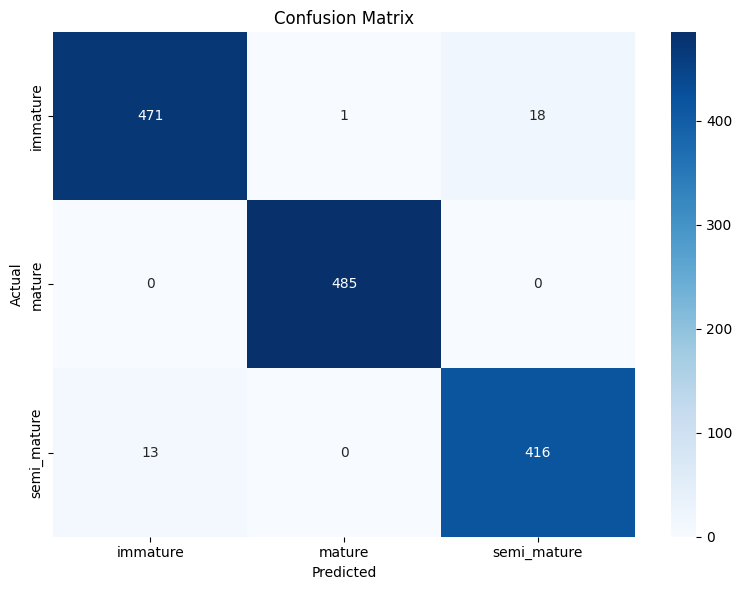


 Evaluation Completed Successfully.


In [9]:
# ============================================================
# COMPLETE FIXED MODEL LOAD + TEST + REPORT (ONE CELL)
# ============================================================

import torch
import torch.nn as nn
import torchvision.models as models
from torchvision import datasets, transforms

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import classification_report, confusion_matrix


# ----------------------------
# CONFIG (EDIT PATHS)
# ----------------------------

MODEL_PATH = r"C:\Users\cl502_15\Downloads\Mtech Major Project\Mtech Major Project\DeepLearningModels\digital_best_resnet50_guava.pth"

TEST_DIR = r"C:\Users\cl502_15\Downloads\Mtech Major Project\Mtech Major Project\Dataset\Maturity\train test val split for digital\test"

BATCH_SIZE = 32
IMG_SIZE = 224
DROPOUT = 0.5   # Change if you used different


# ----------------------------
# Device
# ----------------------------

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ----------------------------
# Transforms
# ----------------------------

test_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])


# ----------------------------
# Load Test Dataset
# ----------------------------

test_dataset = datasets.ImageFolder(
    root=TEST_DIR,
    transform=test_transforms
)

test_loader = torch.utils.data.DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=4,
    pin_memory=True
)

print(" Test dataset loaded.")
print(" Classes:", test_dataset.classes)


# ----------------------------
# Build Model (MATCH TRAINING)
# ----------------------------

NUM_CLASSES = len(test_dataset.classes)

model = models.resnet50(weights=None)

# IMPORTANT: Sequential FC (matches fc.1.weight)
model.fc = nn.Sequential(
    nn.Dropout(DROPOUT),
    nn.Linear(model.fc.in_features, NUM_CLASSES)
)

model = model.to(device)


# ----------------------------
# Load Weights (Now Compatible)
# ----------------------------

model.load_state_dict(
    torch.load(MODEL_PATH, map_location=device),
    strict=True
)

model.eval()

print(" Model loaded successfully.")


# ----------------------------
# Test Evaluation
# ----------------------------

y_true = []
y_pred = []


with torch.no_grad(), torch.amp.autocast(device_type="cuda"):

    for images, labels in test_loader:

        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        outputs = model(images)

        _, preds = torch.max(outputs, 1)

        y_true.extend(labels.cpu().numpy())
        y_pred.extend(preds.cpu().numpy())


# ----------------------------
# Classification Report
# ----------------------------

class_names = test_dataset.classes

print("\n" + "="*60)
print(" CLASSIFICATION REPORT (TEST SET) ")
print("="*60 + "\n")

print(classification_report(
    y_true,
    y_pred,
    target_names=class_names,
    digits=4
))


# ----------------------------
# Confusion Matrix
# ----------------------------

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.tight_layout()
plt.show()


print("\n Evaluation Completed Successfully.")